In [45]:
import pandas as pd

a = pd.read_csv("Wholesale customers data.csv")
print(a)

     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4          5185  
..          ...

In [46]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [47]:
a.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [48]:
a.tail()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125
439,1,3,2787,1698,2510,65,477,52


In [49]:
a.shape

(440, 8)

In [50]:
a.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [51]:
a.duplicated().sum()

np.int64(0)

In [52]:
a1 = a.drop(columns=['Channel', 'Region'], axis=1)
print(a1)

     Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0    12669   9656     7561     214              2674        1338
1     7057   9810     9568    1762              3293        1776
2     6353   8808     7684    2405              3516        7844
3    13265   1196     4221    6404               507        1788
4    22615   5410     7198    3915              1777        5185
..     ...    ...      ...     ...               ...         ...
435  29703  12051    16027   13135               182        2204
436  39228   1431      764    4510                93        2346
437  14531  15488    30243     437             14841        1867
438  10290   1981     2232    1038               168        2125
439   2787   1698     2510      65               477          52

[440 rows x 6 columns]


In [53]:
from sklearn.preprocessing import StandardScaler
a1_scaled = StandardScaler().fit_transform(a1)
print(a1_scaled)

[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 ...
 [ 0.20032554  1.31467078  2.34838631 -0.54337975  2.51121768  0.12145607]
 [-0.13538389 -0.51753572 -0.60251388 -0.41944059 -0.56977032  0.21304614]
 [-0.72930698 -0.5559243  -0.57322717 -0.62009417 -0.50488752 -0.52286938]]


In [54]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(a1_scaled)
print(kmeans.labels_)

[0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1
 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 1 0 0 0]


In [55]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(a1_scaled)
    wcss.append(kmeans.inertia_)

In [56]:
wcss

[2639.9999999999977,
 2276.14395112841,
 1655.3937971225905,
 1333.8149588538517,
 1128.5776377246543,
 971.4969981800963,
 828.5102303294663,
 789.1964232877635,
 668.9585775548952,
 617.8061432290551]

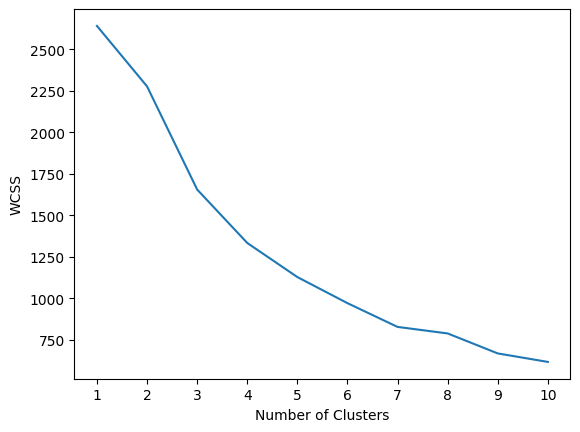

In [57]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [58]:
kmeans=KMeans(n_clusters=1,init="k-means++")
kmeans.fit_predict(a1_scaled)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [59]:
from sklearn.metrics import silhouette_score

silhouette_coefficients = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(a1_scaled)
    score = silhouette_score(a1_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [60]:
silhouette_coefficients

[np.float64(0.6507070462309338),
 np.float64(0.5428636478701424),
 np.float64(0.3371935666756086),
 np.float64(0.3599088743671391),
 np.float64(0.304033689790884),
 np.float64(0.2802456777592455),
 np.float64(0.28861791357951727),
 np.float64(0.2751044379805915),
 np.float64(0.30246516390357314)]

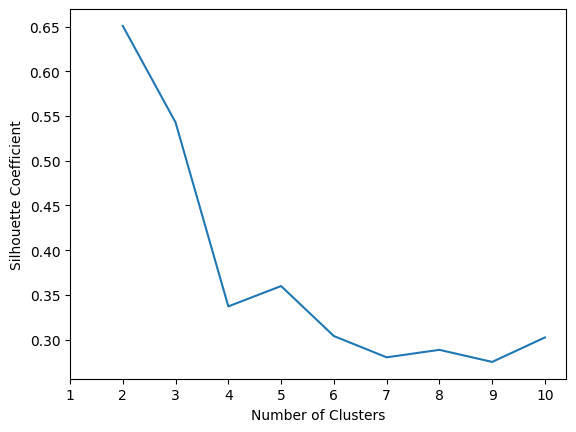

In [61]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [62]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [63]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_scaled = pca.fit_transform(a1_scaled)
print(pca_scaled)

[[ 1.93290546e-01 -3.05099963e-01]
 [ 4.34419896e-01 -3.28412623e-01]
 [ 8.11143234e-01  8.15095701e-01]
 [-7.78647832e-01  6.52753734e-01]
 [ 1.66287259e-01  1.27143372e+00]
 [-1.56169932e-01 -2.95140988e-01]
 [-3.35288404e-01 -5.25003258e-01]
 [ 1.40586434e-01 -2.30992687e-01]
 [-5.17319541e-01 -6.59362827e-01]
 [ 1.59210908e+00 -7.41011332e-01]
 [ 6.38085945e-01 -4.01825201e-01]
 [-9.27692579e-01 -2.19287242e-01]
 [ 9.91362176e-01  6.85910808e-01]
 [ 8.50246760e-01 -8.56919642e-02]
 [ 8.45043794e-01  1.54724325e-01]
 [-9.51585375e-01 -4.95908498e-01]
 [ 5.57558717e-01 -1.02612272e+00]
 [-3.52538598e-01  2.07075910e-01]
 [ 3.16578563e-01  4.42066292e-01]
 [-3.23755737e-01 -7.03586946e-01]
 [-3.20000597e-01  1.56628147e-01]
 [-1.11844720e+00 -2.30527519e-01]
 [-1.76694545e-01  2.14371699e+00]
 [ 4.68565421e+00  3.59867838e+00]
 [ 1.24504208e+00  1.05565966e+00]
 [-1.54114026e-01 -5.22893625e-01]
 [-1.03962354e+00 -3.64796511e-02]
 [-1.09752718e+00 -2.42981966e-01]
 [ 3.12209160e+00 -3

In [64]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(pca_scaled)
distances, indices = neighbors_fit.kneighbors(pca_scaled)

In [65]:
import numpy as np
distances = np.sort(distances[:, 1], axis=0)

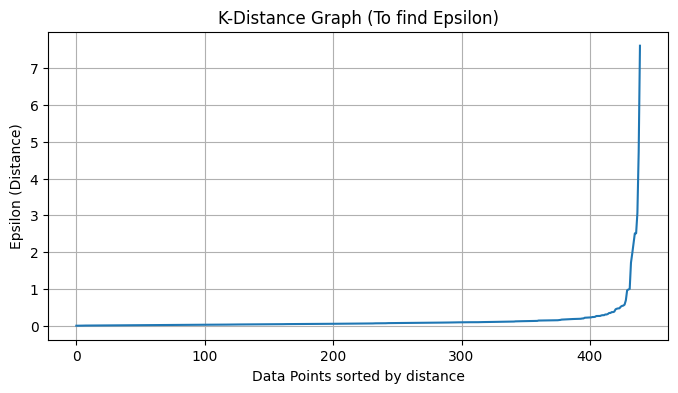

In [66]:
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("K-Distance Graph (To find Epsilon)")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("Epsilon (Distance)")
plt.grid(True)
plt.show()

In [67]:
dbscan = DBSCAN(eps=0.6, min_samples=4)
clusters = dbscan.fit_predict(pca_scaled)

In [68]:
if len(set(clusters)) > 1:
    score = silhouette_score(pca_scaled, clusters)
    print(f"Silhouette Score: {score:.3f}")
else:
    print("DBSCAN found only one cluster or all noise. Adjust eps/min_samples.")

Silhouette Score: 0.692


In [69]:
print("Cluster Labels (including -1 for noise):", np.unique(clusters))

Cluster Labels (including -1 for noise): [-1  0]


In [70]:
dbscan.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,
        0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1, -1, -1,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [71]:
len(dbscan.labels_)

440

In [72]:
import pandas as pd
pd.Series(clusters).value_counts()

,count
0,413
-1,27
